# ЛР №6. Использование композиций алгоритмов при решении задач машинного обучения

[См. общую информацию по лабораторным работам.](https://colab.research.google.com/drive/1ziTOO6CE1QtO6Yxc4Ktyqg-eLyDl7ePG#scrollTo=CFkh9TzuZaoq)

Выполните задания к **10 лабораторной работе из методички**.

## Теоретические сведения
1. Семинары и лекции ИСП РАН из курса по ML (весна 2025):
* [Решающие деревья](https://github.com/kiranov/ISP_ML1_2025_st/blob/master/lectures/lecture8/ISP_decision_trees_lecture_8.pdf)
* [Решающие деревья (семинар)](https://github.com/kiranov/ISP_ML1_2025_st/blob/master/seminars/seminar8/08_decision_tree.ipynb)
* [Ансамблирование](https://github.com/kiranov/ISP_ML1_2025_st/blob/master/lectures/lecture9/ISP_RAS_ML_Spring_2025_9th_lecture%20(2).pdf)
* [Градиентный бустинг. Сравнение библиотек](https://github.com/kiranov/ISP_ML1_2025_st/blob/master/seminars/seminar10/10_boosting.ipynb)
2. [Градиентный бустинг (ШАД)](https://education.yandex.ru/handbook/ml/article/gradientnyj-busting)


## Ход работы

*   Решите задачу **бинарной** классификации для набора данных [NSL-KDD](https://www.unb.ca/cic/datasets/nsl.html). Модель должна предсказывать, содержит ли сетевой трафик атаку или является безвредным трафиком.
* Для градиентного бустинга рекомендуется использовать [XGBClassifier из библиотеки XGBoost](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier). Альтернативы:
    * [GradientBoostingClassifier из Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html);
    * [LightGBM](https://lightgbm.readthedocs.io/en/stable/);
    * [CatBoost](https://catboost.ai/).
*   Также решите задачу при помощи дерева принятия решений ([DecisionTreeClassifier в Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)) и включите полученные результаты в сравнение.
*   После выполнения заданий из методички, решите задачу **многоклассовой** классификации при помощи любого из использованных алгоритмов. Модель должна предсказывать класс атаки, если она содержится в трафике.



## Набор данных NSL-KDD
**NSL-KDD** – один из классических наборов данных для задачи обнаружения атак в сетевом трафике. Был подготовлен в 2009 году University of New Brunswick путём улучшения датасета KDD Cup 1999, который, в свою очередь, основан на датасете DARPA1998.

Оригинальный набор данных был создан путём генерации атак в синтетическом "чистом" трафике, который включает в себя протоколы электронной почты, HTTP, FTP, Telnet, IRC, SNMP. Модель сети объединяет роутер, два сетевых концентратора, устройства под управлением операционных систем Solaris, SunOS, Linux.

Набор данных содержит файлы с характеристиками данных tcpdump датасета DARPA1998. Сетевой трафик был размечен при помощи специальных инструментов, каждая запись в датасете соответствует сетевой сессии.

Используемая далее версия содержит **42 признака**:
*   3 признака для контента (характеристики содержимого внутри соединения, полученные на основе знаний о предметной области);
*    38 числовых признаков (базовые характеристики индивидуальных TCP-соединений и характеристики трафика);
*    класс записи (нормальная/аномальная – или вид аномалии, т.е. атаки).

Типы атак в датасете:
*    DoS (Denial-of-Service) − back, land, Neptune, pod, smurf, teardrop;
*    U2R (User-to-Root) − buffer overflow, loadmodule, perl, rootkit;
*    R2L (Remote to Local Attack) − ftp-write, guess-passwd, imap, multihop, phf, spy, warezclient, warezmaster;
*    Probbing Attack − ipsweep, nmap, portsweep, satan.



Для загрузки набора данных NSL-KDD используйте следующий код (или выберите другой способ [на Kaggle](https://www.kaggle.com/datasets/kiranmahesh/nslkdd)):

In [2]:
import kagglehub

# Download latest version.
path = kagglehub.dataset_download("kiranmahesh/nslkdd")

print("Path to dataset files:", path)

/usr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.56M/2.56M [00:02<00:00, 1.31MB/s]

Extracting files...
Path to dataset files: /home/supy/.cache/kagglehub/datasets/kiranmahesh/nslkdd/versions/3


## Решение

Train shape: (125973, 42)
Test shape:  (22544, 42)

Распределение меток (train):
labels
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


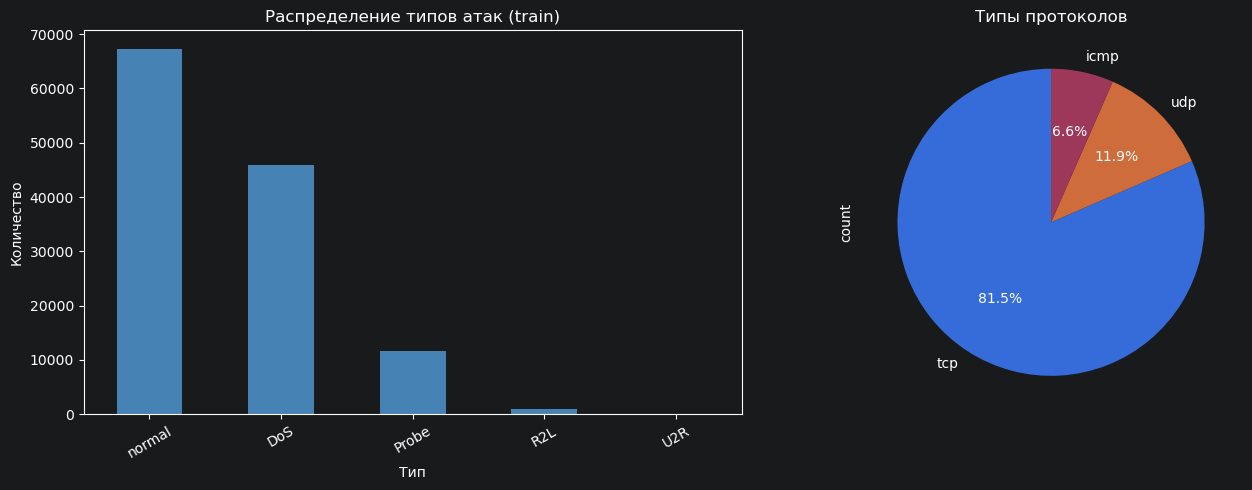


Binary train: [67343 58630]
Binary test:  [11245 11299]

=== Decision Tree (Binary) ===
              precision    recall  f1-score   support

      Normal       0.89      0.99      0.94     11245
      Attack       0.99      0.88      0.93     11299

    accuracy                           0.94     22544
   macro avg       0.94      0.94      0.94     22544
weighted avg       0.94      0.94      0.94     22544

Accuracy: 0.9363
F1 (macro): 0.9361

=== XGBoost (Binary) ===
              precision    recall  f1-score   support

      Normal       0.90      0.99      0.94     11245
      Attack       0.99      0.89      0.94     11299

    accuracy                           0.94     22544
   macro avg       0.94      0.94      0.94     22544
weighted avg       0.94      0.94      0.94     22544

Accuracy: 0.9387
F1 (macro): 0.9386
ROC-AUC: 0.9928


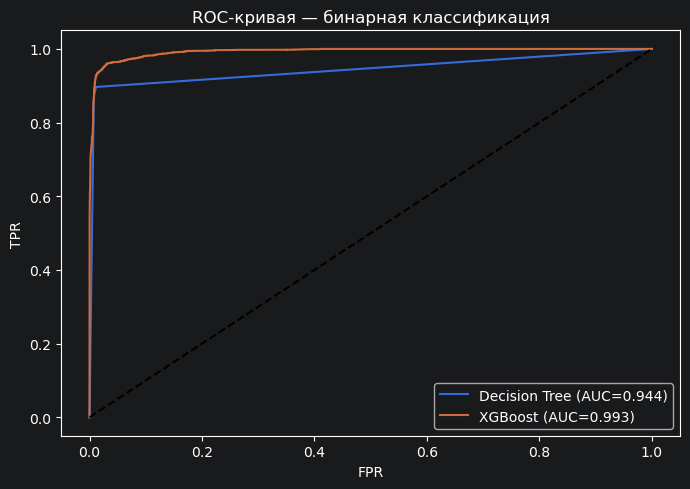

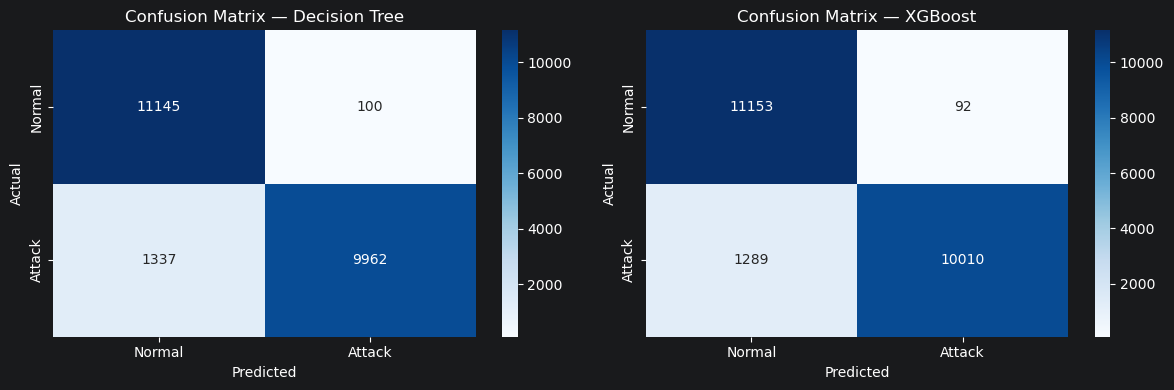

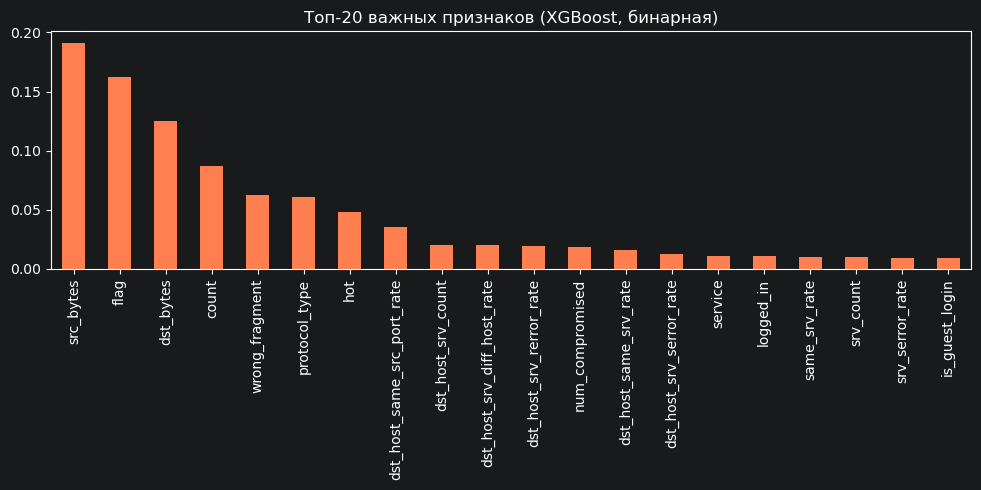


=== Сравнение моделей (бинарная классификация) ===
       Модель  Accuracy  F1 macro  F1 weighted
Decision Tree  0.936258  0.936082     0.936074
      XGBoost  0.938742  0.938584     0.938577

Классы многоклассовой задачи: ['DoS' 'Probe' 'R2L' 'U2R' 'normal']

=== XGBoost (Многоклассовая) ===
              precision    recall  f1-score   support

         DoS       0.99      0.95      0.97      8095
       Probe       0.94      0.90      0.92      2157
         R2L       0.99      0.17      0.29       968
         U2R       1.00      0.18      0.30        79
      normal       0.89      0.99      0.94     11245

    accuracy                           0.93     22544
   macro avg       0.96      0.64      0.68     22544
weighted avg       0.94      0.93      0.92     22544

Accuracy: 0.9301


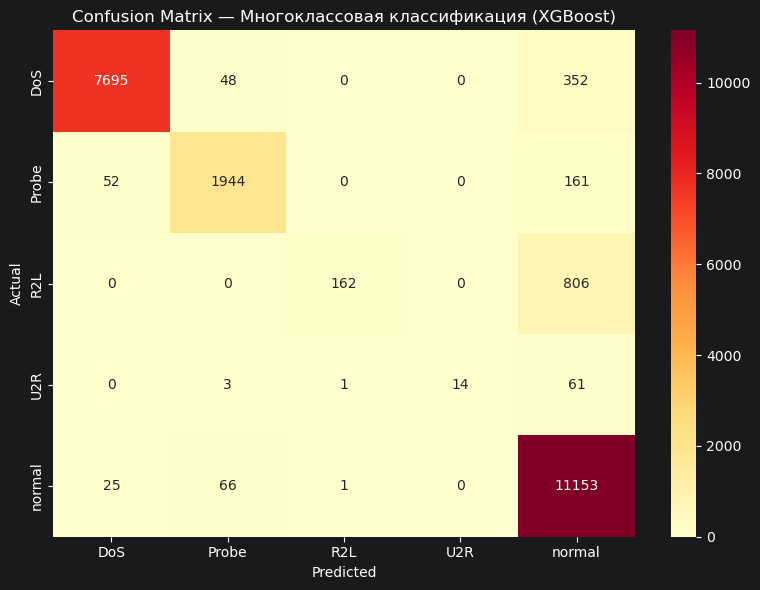

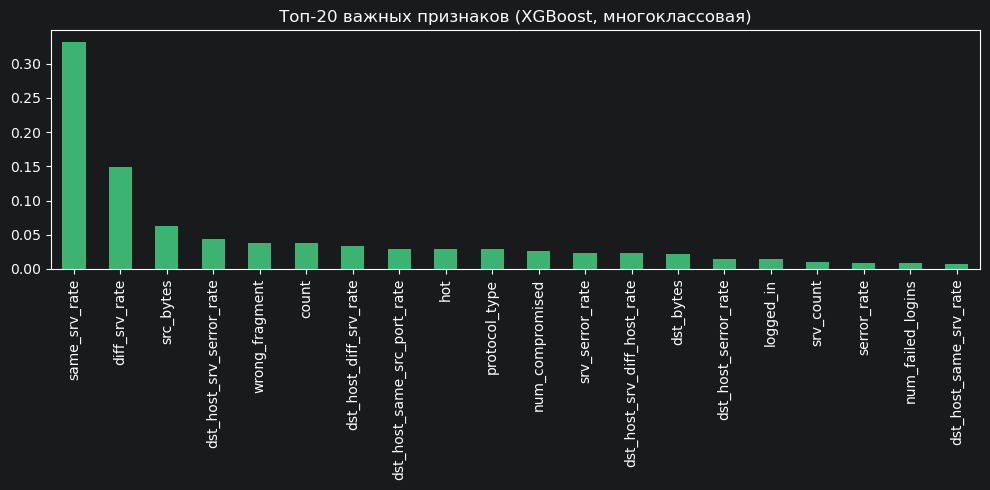


ИТОГОВЫЕ РЕЗУЛЬТАТЫ

--- Бинарная классификация ---
       Модель  Accuracy  F1 macro  F1 weighted
Decision Tree  0.936258  0.936082     0.936074
      XGBoost  0.938742  0.938584     0.938577

--- Многоклассовая классификация (XGBoost) ---
Accuracy:    0.9301
F1 macro:    0.6834
F1 weighted: 0.9177


In [6]:
# ==============================================================
# ЛР №6. Композиции алгоритмов — NSL-KDD
# Бинарная + многоклассовая классификация
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score, roc_curve
)
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# ==============================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ==============================================================

path = "/home/supy/.cache/kagglehub/datasets/kiranmahesh/nslkdd/versions/3"

df_train = pd.read_csv(f"{path}/kdd_train.csv")
df_test  = pd.read_csv(f"{path}/kdd_test.csv")

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")
df_train.head(3)

# ==============================================================
# 2. EDA
# ==============================================================

print("\nРаспределение меток (train):")
print(df_train["labels"].value_counts())

attack_map = {
    # DoS
    "back": "DoS", "land": "DoS", "neptune": "DoS",
    "pod": "DoS", "smurf": "DoS", "teardrop": "DoS",
    "mailbomb": "DoS", "apache2": "DoS", "processtable": "DoS",
    "udpstorm": "DoS",
    # U2R
    "buffer_overflow": "U2R", "loadmodule": "U2R",
    "perl": "U2R", "rootkit": "U2R", "httptunnel": "U2R",
    "ps": "U2R", "sqlattack": "U2R", "xterm": "U2R",
    # R2L
    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L",
    "multihop": "R2L", "phf": "R2L", "spy": "R2L",
    "warezclient": "R2L", "warezmaster": "R2L", "named": "R2L",
    "sendmail": "R2L", "snmpgetattack": "R2L", "snmpguess": "R2L",
    "worm": "R2L", "xlock": "R2L", "xsnoop": "R2L",
    # Probe
    "ipsweep": "Probe", "nmap": "Probe",
    "portsweep": "Probe", "satan": "Probe",
    "mscan": "Probe", "saint": "Probe",
    # Normal
    "normal": "normal"
}

df_train["attack_type"] = df_train["labels"].map(attack_map).fillna("Other")
df_test["attack_type"]  = df_test["labels"].map(attack_map).fillna("Other")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_train["attack_type"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Распределение типов атак (train)")
axes[0].set_xlabel("Тип"); axes[0].set_ylabel("Количество")
axes[0].tick_params(axis='x', rotation=30)

df_train["protocol_type"].value_counts().plot(kind="pie", ax=axes[1],
                                               autopct="%1.1f%%", startangle=90)
axes[1].set_title("Типы протоколов")
plt.tight_layout(); plt.show()

# ==============================================================
# 3. ПРЕДОБРАБОТКА
# ==============================================================

def preprocess(df_tr, df_te):
    df_tr = df_tr.copy()
    df_te = df_te.copy()

    cat_cols = ["protocol_type", "service", "flag"]
    le = LabelEncoder()

    for col in cat_cols:
        combined = pd.concat([df_tr[col], df_te[col]], axis=0)
        le.fit(combined)
        df_tr[col] = le.transform(df_tr[col])
        df_te[col] = le.transform(df_te[col])

    return df_tr, df_te

df_train_p, df_test_p = preprocess(df_train, df_test)

feature_cols = [c for c in df_train_p.columns
                if c not in ("labels", "attack_type")]

X_train = df_train_p[feature_cols].values
X_test  = df_test_p[feature_cols].values

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ==============================================================
# 4. БИНАРНАЯ КЛАССИФИКАЦИЯ
# ==============================================================

y_bin_train = (df_train_p["labels"] != "normal").astype(int).values
y_bin_test  = (df_test_p["labels"]  != "normal").astype(int).values

print(f"\nBinary train: {np.bincount(y_bin_train)}")
print(f"Binary test:  {np.bincount(y_bin_test)}")

# --- 4.1 Decision Tree ---
dt = DecisionTreeClassifier(max_depth=15, min_samples_leaf=5, random_state=42)
dt.fit(X_train_sc, y_bin_train)
y_pred_dt = dt.predict(X_test_sc)

print("\n=== Decision Tree (Binary) ===")
print(classification_report(y_bin_test, y_pred_dt,
                             target_names=["Normal", "Attack"]))
print(f"Accuracy: {accuracy_score(y_bin_test, y_pred_dt):.4f}")
print(f"F1 (macro): {f1_score(y_bin_test, y_pred_dt, average='macro'):.4f}")

# --- 4.2 XGBoost ---
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_sc, y_bin_train,
        eval_set=[(X_test_sc, y_bin_test)],
        verbose=False)
y_pred_xgb  = xgb.predict(X_test_sc)
y_proba_xgb = xgb.predict_proba(X_test_sc)[:, 1]

print("\n=== XGBoost (Binary) ===")
print(classification_report(y_bin_test, y_pred_xgb,
                             target_names=["Normal", "Attack"]))
print(f"Accuracy: {accuracy_score(y_bin_test, y_pred_xgb):.4f}")
print(f"F1 (macro): {f1_score(y_bin_test, y_pred_xgb, average='macro'):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_bin_test, y_proba_xgb):.4f}")

# --- 4.3 ROC-кривая ---
fpr_dt,  tpr_dt,  _ = roc_curve(y_bin_test,
                                  dt.predict_proba(X_test_sc)[:, 1])
fpr_xgb, tpr_xgb, _ = roc_curve(y_bin_test, y_proba_xgb)

plt.figure(figsize=(7, 5))
plt.plot(fpr_dt,  tpr_dt,  label=f"Decision Tree (AUC={roc_auc_score(y_bin_test, dt.predict_proba(X_test_sc)[:,1]):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_bin_test, y_proba_xgb):.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC-кривая — бинарная классификация")
plt.legend(); plt.tight_layout(); plt.show()

# --- 4.4 Confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title in [
    (axes[0], y_pred_dt,  "Decision Tree"),
    (axes[1], y_pred_xgb, "XGBoost"),
]:
    cm = confusion_matrix(y_bin_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    ax.set_title(f"Confusion Matrix — {title}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

# --- 4.5 Важность признаков (XGBoost) ---
fi = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
fi.head(20).plot(kind="bar", color="coral")
plt.title("Топ-20 важных признаков (XGBoost, бинарная)")
plt.tight_layout(); plt.show()

# --- 4.6 Сравнительная таблица ---
results_bin = pd.DataFrame({
    "Модель":      ["Decision Tree", "XGBoost"],
    "Accuracy":    [accuracy_score(y_bin_test, y_pred_dt),
                    accuracy_score(y_bin_test, y_pred_xgb)],
    "F1 macro":    [f1_score(y_bin_test, y_pred_dt, average="macro"),
                    f1_score(y_bin_test, y_pred_xgb, average="macro")],
    "F1 weighted": [f1_score(y_bin_test, y_pred_dt, average="weighted"),
                    f1_score(y_bin_test, y_pred_xgb, average="weighted")],
})
print("\n=== Сравнение моделей (бинарная классификация) ===")
print(results_bin.to_string(index=False))

# ==============================================================
# 5. МНОГОКЛАССОВАЯ КЛАССИФИКАЦИЯ
# ==============================================================

le_multi = LabelEncoder()
y_multi_train = le_multi.fit_transform(df_train_p["attack_type"])
y_multi_test  = le_multi.transform(
    df_test_p["attack_type"].map(
        lambda x: x if x in le_multi.classes_ else "Other"
    )
)

print(f"\nКлассы многоклассовой задачи: {le_multi.classes_}")

xgb_mc = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(le_multi.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)
xgb_mc.fit(X_train_sc, y_multi_train,
           eval_set=[(X_test_sc, y_multi_test)],
           verbose=False)
y_pred_mc = xgb_mc.predict(X_test_sc)

print("\n=== XGBoost (Многоклассовая) ===")
print(classification_report(y_multi_test, y_pred_mc,
                             target_names=le_multi.classes_))
print(f"Accuracy: {accuracy_score(y_multi_test, y_pred_mc):.4f}")

# --- Confusion matrix многоклассовая ---
cm_mc = confusion_matrix(y_multi_test, y_pred_mc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mc, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=le_multi.classes_,
            yticklabels=le_multi.classes_)
plt.title("Confusion Matrix — Многоклассовая классификация (XGBoost)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

# --- Важность признаков (XGBoost multi) ---
fi_mc = pd.Series(xgb_mc.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
fi_mc.head(20).plot(kind="bar", color="mediumseagreen")
plt.title("Топ-20 важных признаков (XGBoost, многоклассовая)")
plt.tight_layout(); plt.show()

# ==============================================================
# 6. ИТОГОВОЕ СРАВНЕНИЕ
# ==============================================================

print("\n" + "="*55)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*55)
print("\n--- Бинарная классификация ---")
print(results_bin.to_string(index=False))
print(f"\n--- Многоклассовая классификация (XGBoost) ---")
print(f"Accuracy:    {accuracy_score(y_multi_test, y_pred_mc):.4f}")
print(f"F1 macro:    {f1_score(y_multi_test, y_pred_mc, average='macro'):.4f}")
print(f"F1 weighted: {f1_score(y_multi_test, y_pred_mc, average='weighted'):.4f}")

## Контрольные вопросы.


*   Ответьте на вопросы из методички к 9 лабораторной работе.
*   Ответьте на вопросы из методички к 10 лабораторной работе.
*   Объясните результаты для случая многоклассовой классификации. Как можно их улучшить?
*   Чем отличаются реализации градиентного бустинга из библиотек LightGBM, XGBoost и CatBoost? В чём их преимущества по сравнению с реализацией Scikit-learn?
*   Как вы считаете, какой основной недостаток набора данных NSL-KDD?

